# S4/S5 · AndinaLog 03B · Evidencia 3 · Alerta térmica en 60 minutos

**Pregunta:** ¿Qué información disponible en una lectura podría ayudar a anticipar una desviación térmica durante los próximos 60 minutos?

Este notebook **solo lee** los Silver de IoT, Productos y Flota. Conserva la granularidad temporal (**una fila por lectura**), valida los joins, construye variables con información presente o pasada, explora su relación con `desviacion_proximos_60min_flag` y prepara un conjunto de modelado y una separación temporal candidata. **No entrena ni elige un modelo final.** No modifica los Silver.

El significado y la generación exacta del target deben documentarse antes de evaluar cualquier modelo. El notebook usa la bandera recibida, sin afirmar que una alerta se haya cumplido ni recalcularla con datos futuros.

## 1 · Contrato predictivo y preguntas

- **Decisión:** priorizar revisión o intervención preventiva durante un viaje.
- **Unidad:** lectura de IoT de un viaje en `timestamp`.
- **Momento de predicción:** al recibir esa lectura.
- **Target (`y`):** `desviacion_proximos_60min_flag`, recibido en IoT Silver.
- **Predictores candidatos (`X`):** temperatura y humedad actuales, temperatura previa, cambio respecto a la lectura previa, distancia al umbral del producto, categoría logística y tipo de camión.
- **Regla temporal:** ninguna feature puede usar observaciones posteriores a `timestamp`; el target nunca forma parte de `X`.

Preguntas EDA: ¿qué proporción de lecturas tiene target 1?, ¿cómo cambian las mediciones y tendencias entre clases?, ¿qué grupos concentran alertas y con qué tamaño?, ¿cuántas filas pierden utilidad predictiva por claves, secuencia o valores faltantes?

## 2 · Configuración y carga

Ejecuta desde la raíz o una subcarpeta del proyecto. Si las rutas no se encuentran, define `RUTAS_MANUALES`. En Colab, ajusta `RUTA_PROYECTO_DRIVE`. Se aceptan las estructuras `S4/...` y `proyecto-integrador/...` utilizadas en los notebooks previos.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ENTORNO = "auto"  # auto, local o drive
RUTA_PROYECTO_DRIVE = "/content/drive/MyDrive/GIAD"
RUTAS_MANUALES = {"iot": None, "productos": None, "flota": None}
FRACCION_TRAIN_OBJETIVO = 0.80
ARCHIVOS = {
    "iot": "andinalog_iot_telemetry_silver.csv",
    "productos": "andinalog_productos_silver.csv",
    "flota": "andinalog_flota_silver.csv",
}
SUBRUTAS = {
    "iot": ["S4/andinalog_iot_telemetry/notebook2/salidas", "proyecto-integrador/andinalog_iot_telemetry/notebook2/salidas"],
    "productos": ["proyecto-integrador/andinalog_productos/notebook2/salidas", "S4/andinalog_productos/notebook2/salidas"],
    "flota": ["proyecto-integrador/andinalog_flota/notebook2/salidas", "S4/andinalog_flota/notebook2/salidas"],
}

def raices_posibles():
    entorno = ENTORNO
    if entorno == "auto":
        entorno = "drive" if "google.colab" in sys.modules else "local"
    if entorno == "drive":
        from google.colab import drive
        drive.mount("/content/drive")
        return [Path(RUTA_PROYECTO_DRIVE)]
    if entorno == "local":
        return [Path.cwd(), *Path.cwd().parents]
    raise ValueError("ENTORNO debe ser auto, local o drive")

def encontrar_silver(nombre):
    manual = RUTAS_MANUALES[nombre]
    if manual is not None:
        ruta = Path(manual)
        if not ruta.is_file():
            raise FileNotFoundError(f"No existe {nombre}: {ruta}")
        return ruta
    for raiz in raices_posibles():
        for subruta in SUBRUTAS[nombre]:
            ruta = raiz / subruta / ARCHIVOS[nombre]
            if ruta.is_file():
                return ruta
    raise FileNotFoundError(f"No se encontró {ARCHIVOS[nombre]}. Indica su ruta en RUTAS_MANUALES['{nombre}'].")

rutas = {nombre: encontrar_silver(nombre) for nombre in ARCHIVOS}
for nombre, ruta in rutas.items():
    print(nombre, "→", ruta)

def leer_silver(ruta):
    return pd.read_csv(ruta, dtype="string", encoding="utf-8-sig", keep_default_na=False)

iot_raw, productos_raw, flota_raw = (leer_silver(rutas[n]) for n in ("iot", "productos", "flota"))

iot → c:\Users\remrodri\Github\practicasNotebookColab\proyecto-integrador\andinalog_iot_telemetry\notebook2\salidas\andinalog_iot_telemetry_silver.csv
productos → c:\Users\remrodri\Github\practicasNotebookColab\proyecto-integrador\andinalog_productos\notebook2\salidas\andinalog_productos_silver.csv
flota → c:\Users\remrodri\Github\practicasNotebookColab\proyecto-integrador\andinalog_flota\notebook2\salidas\andinalog_flota_silver.csv


## 3 · Validación de las fuentes

Se exigen claves y dimensiones únicas, timestamps válidos y banderas binarias. La comprobación de `viaje_id + timestamp` evita ordenar una secuencia ambigua. Las conversiones son solo en memoria.

In [2]:
REQUERIDAS = {
    "iot": {"timestamp", "viaje_id", "order_id", "camion_id", "producto_id",
            "temperatura_cabina_c", "humedad_cabina_pct", "desviacion_termica_flag",
            "desviacion_proximos_60min_flag"},
    "productos": {"producto_id", "categoria_logistica", "temperatura_conservacion_requerida_c",
                  "tolerancia_temperatura_c"},
    "flota": {"camion_id", "tipo_camion"},
}
fuentes = {"iot": iot_raw, "productos": productos_raw, "flota": flota_raw}
for nombre, tabla in fuentes.items():
    faltantes = REQUERIDAS[nombre] - set(tabla.columns)
    if tabla.empty or faltantes:
        raise ValueError(f"{nombre}: Silver vacío o columnas faltantes {sorted(faltantes)}")
    claves = {"iot": ["viaje_id", "order_id", "camion_id", "producto_id"],
              "productos": ["producto_id"], "flota": ["camion_id"]}[nombre]
    if tabla[claves].eq("").any().any() or tabla[claves].isna().any().any():
        raise ValueError(f"{nombre}: claves vacías")
if productos_raw["producto_id"].duplicated().any() or flota_raw["camion_id"].duplicated().any():
    raise ValueError("Productos/Flota deben ser únicos por producto_id/camion_id")

iot = iot_raw.copy(deep=True)
productos = productos_raw.copy(deep=True)
flota = flota_raw.copy(deep=True)
iot["timestamp"] = pd.to_datetime(iot["timestamp"], errors="raise")
for col in ["temperatura_cabina_c", "humedad_cabina_pct", "desviacion_termica_flag",
            "desviacion_proximos_60min_flag"]:
    iot[col] = pd.to_numeric(iot[col], errors="raise")
for col in ["temperatura_conservacion_requerida_c", "tolerancia_temperatura_c"]:
    productos[col] = pd.to_numeric(productos[col], errors="raise")
if iot[["timestamp", "temperatura_cabina_c", "humedad_cabina_pct",
        "desviacion_termica_flag", "desviacion_proximos_60min_flag"]].isna().any().any():
    raise ValueError("IoT contiene mediciones, fecha o banderas nulas")
for col in ["desviacion_termica_flag", "desviacion_proximos_60min_flag"]:
    if not iot[col].isin([0, 1]).all():
        raise ValueError(f"{col} debe ser 0/1")
if iot["temperatura_cabina_c"].lt(-273.15).any() or iot["temperatura_cabina_c"].eq(-999).any():
    raise ValueError("IoT contiene temperatura imposible o centinela -999")
if not iot["humedad_cabina_pct"].between(0, 100).all():
    raise ValueError("IoT contiene humedad fuera de 0 a 100 %")
if productos[["temperatura_conservacion_requerida_c", "tolerancia_temperatura_c"]].isna().any().any():
    raise ValueError("Productos contiene parámetros térmicos nulos")
if productos["tolerancia_temperatura_c"].lt(0).any():
    raise ValueError("Productos contiene tolerancia negativa")
if iot.duplicated(["viaje_id", "timestamp"]).any():
    raise ValueError("IoT contiene viaje_id + timestamp duplicados")

display(pd.DataFrame([{"fuente": n, "filas": len(t), "columnas": len(t.columns)} for n, t in fuentes.items()]))
print("Viajes:", iot["viaje_id"].nunique(), "| periodo:", iot["timestamp"].min(), "a", iot["timestamp"].max())

,fuente,filas,columnas
0,iot,28425,10
1,productos,50,7
2,flota,28,4


Viajes: 1200 | periodo: 2026-08-01 00:10:00 a 2026-08-31 11:11:00


## 4 · Granularidad, cobertura y joins

Aquí **no se agrega IoT a una fila por viaje**. Productos y Flota son dimensiones N:1, por lo que se unen a cada lectura. Se conserva cada lectura con `left join`, se mide la cobertura y se verifica que el número de filas no cambie.

In [3]:
cobertura = pd.DataFrame([
    {"dimensión": "Productos", "lecturas_sin_match": int((~iot["producto_id"].isin(productos["producto_id"])).sum()),
     "claves_distintas_sin_match": int(iot.loc[~iot["producto_id"].isin(productos["producto_id"]), "producto_id"].nunique())},
    {"dimensión": "Flota", "lecturas_sin_match": int((~iot["camion_id"].isin(flota["camion_id"])).sum()),
     "claves_distintas_sin_match": int(iot.loc[~iot["camion_id"].isin(flota["camion_id"]), "camion_id"].nunique())},
])
display(cobertura)

analitico = iot.merge(
    productos[["producto_id", "categoria_logistica", "temperatura_conservacion_requerida_c",
               "tolerancia_temperatura_c"]],
    on="producto_id", how="left", validate="many_to_one", indicator="match_producto"
).merge(
    flota[["camion_id", "tipo_camion"]],
    on="camion_id", how="left", validate="many_to_one", indicator="match_flota"
)
if len(analitico) != len(iot) or analitico.duplicated(["viaje_id", "timestamp"]).any():
    raise ValueError("El join alteró la granularidad de las lecturas")
assert analitico["desviacion_proximos_60min_flag"].sum() == iot["desviacion_proximos_60min_flag"].sum()
print("Lecturas antes/después del join:", len(iot), len(analitico))
display(analitico[["match_producto", "match_flota"]].value_counts(dropna=False).rename("lecturas").reset_index())

,dimensión,lecturas_sin_match,claves_distintas_sin_match
0,Productos,4984,10
1,Flota,2389,2


Lecturas antes/después del join: 28425 28425


,match_producto,match_flota,lecturas
0,both,both,21428
1,left_only,both,4608
2,both,left_only,2013
3,left_only,left_only,376
4,both,right_only,0
5,left_only,right_only,0
6,right_only,left_only,0
7,right_only,both,0
8,right_only,right_only,0


## 5 · Comprobar continuidad de cada viaje

El notebook de IoT individual detectó viajes con más de un `camion_id`. Para evitar una pendiente que mezcle vehículos o productos, se identifican viajes con más de una combinación de `order_id`, `camion_id` y `producto_id`. **Permanecen en el EDA descriptivo**, pero no entran en el conjunto listo para modelar hasta aclarar su identidad física. No se supone que todos los viajes tengan exactamente 24 lecturas: se informa la distribución y los intervalos reales.

In [4]:
identidad_viaje = analitico.groupby("viaje_id").agg(
    ordenes=("order_id", "nunique"), camiones=("camion_id", "nunique"),
    productos=("producto_id", "nunique"), lecturas=("timestamp", "size"),
)
identidad_viaje["estable"] = identidad_viaje[["ordenes", "camiones", "productos"]].eq(1).all(axis=1)
viajes_ambiguos = identidad_viaje.index[~identidad_viaje["estable"]]
print("Viajes con identidad estable:", int(identidad_viaje["estable"].sum()))
print("Viajes con varias órdenes/camiones/productos:", len(viajes_ambiguos))
print("Lecturas en viajes ambiguos:", int(analitico["viaje_id"].isin(viajes_ambiguos).sum()))
display(identidad_viaje["lecturas"].describe(percentiles=[.25, .5, .75]).to_frame("lecturas_por_viaje").round(2))
if len(viajes_ambiguos):
    display(identidad_viaje.loc[viajes_ambiguos].head(10))

Viajes con identidad estable: 1200
Viajes con varias órdenes/camiones/productos: 0
Lecturas en viajes ambiguos: 0


,lecturas_por_viaje
count,1200.00
mean,23.69
std,0.55
min,21.00
25%,23.00
50%,24.00
75%,24.00
max,24.00


## 6 · Variables disponibles al momento de lectura

Se ordena por `viaje_id` y `timestamp`; el rezago se calcula **dentro de cada viaje**. `temp_pendiente_c_por_min` divide el cambio por el intervalo real entre lecturas, sin asumir una cadencia fija. `distancia_umbral_c` es negativa dentro de la tolerancia y positiva fuera. Se calcula con parámetros del producto; su interpretación depende de que esos parámetros estuvieran disponibles cuando se emitió la lectura.

No se utiliza `desviacion_termica_flag` como predictor por defecto: primero debe revisarse su regla de generación y si forma parte de la definición de la bandera futura. Tampoco se usan agregados de todo el viaje, valores posteriores ni el propio target como features.

In [5]:
analitico = analitico.sort_values(["viaje_id", "timestamp"], kind="mergesort").reset_index(drop=True)
serie = analitico.groupby("viaje_id", sort=False)
analitico["temp_lag1_c"] = serie["temperatura_cabina_c"].shift(1)
analitico["timestamp_lag1"] = serie["timestamp"].shift(1)
analitico["min_desde_lectura_anterior"] = (
    (analitico["timestamp"] - analitico["timestamp_lag1"]).dt.total_seconds() / 60
)
if analitico["min_desde_lectura_anterior"].dropna().le(0).any():
    raise ValueError("Hay intervalos temporales no positivos dentro de un viaje")
analitico["temp_pendiente_c_por_min"] = (
    (analitico["temperatura_cabina_c"] - analitico["temp_lag1_c"])
    / analitico["min_desde_lectura_anterior"]
)
analitico["distancia_umbral_c"] = (
    (analitico["temperatura_cabina_c"] - analitico["temperatura_conservacion_requerida_c"]).abs()
    - analitico["tolerancia_temperatura_c"]
)
analitico["categoria_eda"] = analitico["categoria_logistica"].replace("", pd.NA).fillna("Sin correspondencia")
analitico["tipo_camion_eda"] = analitico["tipo_camion"].replace("", pd.NA).fillna("Sin correspondencia")
analitico["viaje_identidad_estable"] = analitico["viaje_id"].map(identidad_viaje["estable"])

print("Intervalo entre lecturas (minutos):")
display(analitico["min_desde_lectura_anterior"].describe(percentiles=[.25, .5, .75, .95]).to_frame().round(2))
print("Lecturas sin rezago (inicio de viaje):", int(analitico["temp_lag1_c"].isna().sum()))
assert int(analitico["temp_lag1_c"].isna().sum()) == analitico["viaje_id"].nunique()

Intervalo entre lecturas (minutos):


,min_desde_lectura_anterior
count,27225.00
mean,30.38
std,3.37
min,30.00
25%,30.00
50%,30.00
75%,30.00
95%,30.00
max,90.00


Lecturas sin rezago (inicio de viaje): 1200


## 7 · Validación del dataset analítico y selección candidata

El conjunto candidato exige identidad estable del viaje, match de Producto y Flota, variables predictoras completas y una lectura anterior para calcular tendencia. El descarte se cuantifica; no se eliminan filas del dataset analítico descriptivo. Si el producto o camión no tienen match, la categoría desconocida no se trata como una categoría real.

In [6]:
TARGET = "desviacion_proximos_60min_flag"
FEATURES_NUMERICAS = ["temperatura_cabina_c", "humedad_cabina_pct", "temp_lag1_c",
                     "temp_pendiente_c_por_min", "distancia_umbral_c"]
FEATURES_CATEGORICAS = ["categoria_logistica", "tipo_camion"]
FEATURES = FEATURES_NUMERICAS + FEATURES_CATEGORICAS

apto = (
    analitico["viaje_identidad_estable"]
    & analitico["match_producto"].eq("both")
    & analitico["match_flota"].eq("both")
    & analitico[FEATURES_NUMERICAS].notna().all(axis=1)
    & analitico[FEATURES_CATEGORICAS].ne("").all(axis=1)
    & analitico[TARGET].notna()
)
modelado = analitico.loc[apto].copy()
validacion = pd.DataFrame([
    {"control": "Lecturas Silver", "filas": len(iot)},
    {"control": "Lecturas después de joins", "filas": len(analitico)},
    {"control": "En viajes ambiguos", "filas": int((~analitico["viaje_identidad_estable"]).sum())},
    {"control": "Sin match Productos", "filas": int(analitico["match_producto"].ne("both").sum())},
    {"control": "Sin match Flota", "filas": int(analitico["match_flota"].ne("both").sum())},
    {"control": "Sin lag por inicio de viaje", "filas": int(analitico["temp_lag1_c"].isna().sum())},
    {"control": "Candidatas para modelado", "filas": len(modelado)},
])
display(validacion)
if modelado.empty:
    raise ValueError("Ninguna lectura cumple los requisitos de modelado; revisa cobertura y secuencias")
if TARGET in FEATURES or "desviacion_termica_flag" in FEATURES:
    raise ValueError("Lista de features incluye una bandera excluida del contrato")
assert len(analitico) == len(iot)
assert modelado[FEATURES + [TARGET]].notna().all().all()
assert modelado["viaje_identidad_estable"].all()
print("Dataset analítico validado; conjunto candidato:", len(modelado), "lecturas")

,control,filas
0,Lecturas Silver,28425
1,Lecturas después de joins,28425
2,En viajes ambiguos,0
3,Sin match Productos,4984
4,Sin match Flota,2389
5,Sin lag por inicio de viaje,1200
6,Candidatas para modelado,20523


Dataset analítico validado; conjunto candidato: 20523 lecturas


## 8 · EDA del target y de los predictores

Las tasas por lectura no equivalen a tasas por viaje: las lecturas de un mismo viaje están relacionadas. Además de la prevalencia total se informa cuántos viajes tienen al menos una bandera positiva. Comparar clases ayuda a seleccionar hipótesis, pero no mide capacidad predictiva fuera de muestra.

In [7]:
def balance(tabla, nombre):
    conteo = tabla[TARGET].value_counts().reindex([0, 1], fill_value=0)
    return pd.DataFrame({"conjunto": nombre, "target": conteo.index,
                         "lecturas": conteo.values, "porcentaje": 100 * conteo.values / len(tabla)})

display(pd.concat([balance(analitico, "Analítico completo"), balance(modelado, "Candidato modelado")],
                  ignore_index=True).round(2))
viajes_target = analitico.groupby("viaje_id")[TARGET].max()
print("Viajes con ≥1 target positivo:", int(viajes_target.sum()), "de", len(viajes_target),
      f"({100*viajes_target.mean():.2f} %)")
print("Estadísticas por target, conjunto candidato:")
display(modelado.groupby(TARGET)[FEATURES_NUMERICAS].agg(["count", "median", "mean"]).round(2))

def tasa_por_grupo(columna):
    tabla = modelado.groupby(columna, dropna=False)[TARGET].agg(lecturas="size", positivas="sum", tasa="mean").reset_index()
    tabla["tasa_pct"] = 100 * tabla.pop("tasa")
    return tabla.sort_values("tasa_pct", ascending=False)

print("Por categoría logística")
display(tasa_por_grupo("categoria_logistica").round(2))
print("Por tipo de camión")
display(tasa_por_grupo("tipo_camion").round(2))
print("Por estado de desviación actual (solo descripción, no feature)")
display(pd.crosstab(analitico["desviacion_termica_flag"], analitico[TARGET],
                    rownames=["Desviación actual"], colnames=["Target 60 min"]))

,conjunto,target,lecturas,porcentaje
0,Analítico completo,0,27107,95.36
1,Analítico completo,1,1318,4.64
2,Candidato modelado,0,19593,95.47
3,Candidato modelado,1,930,4.53


Viajes con ≥1 target positivo: 340 de 1200 (28.33 %)
Estadísticas por target, conjunto candidato:


temperatura_cabina_c               \
                                              count median  mean   
desviacion_proximos_60min_flag                                     
0                                             19593   17.1  8.48   
1                                               930   4.99  4.49   

                               humedad_cabina_pct               temp_lag1_c  \
                                            count median   mean       count   
desviacion_proximos_60min_flag                                                
0                                           19593   58.4  60.76       19593   
1                                             930   72.5  69.21         930   

                                            temp_pendiente_c_por_min         \
                               median  mean                    count median   
desviacion_proximos_60min_flag                                                
0                               17.12  8.51                    19593   -0.0   
1                                4.51   3.8                      930   0.01   

                                     distancia_umbral_c               
                                mean              count median  mean  
desviacion_proximos_60min_flag                                        
0                               -0.0              19593  -1.95 -2.49  
1                               0.02                930  -0.93  0.66

Por categoría logística


,categoria_logistica,lecturas,positivas,tasa_pct
1,Fresco,6191,474,7.66
0,Congelado,3806,249,6.54
2,Seco,10526,207,1.97


Por tipo de camión


,tipo_camion,lecturas,positivas,tasa_pct
0,Refrigerado,14748,754,5.11
1,Seco,5775,176,3.05


Por estado de desviación actual (solo descripción, no feature)


Target 60 min,0,1
Desviación actual,,
0,26721,768
1,386,550


## 9 · Visualizaciones

Los histogramas comparan distribuciones por clase sin convertir una asociación en causa. Las barras muestran tasas y tamaños de grupo; los porcentajes de grupos pequeños requieren cautela. La lectura del target exige conocer cómo fue generado y si todos los viajes tienen seguimiento suficiente para observar 60 minutos futuros.

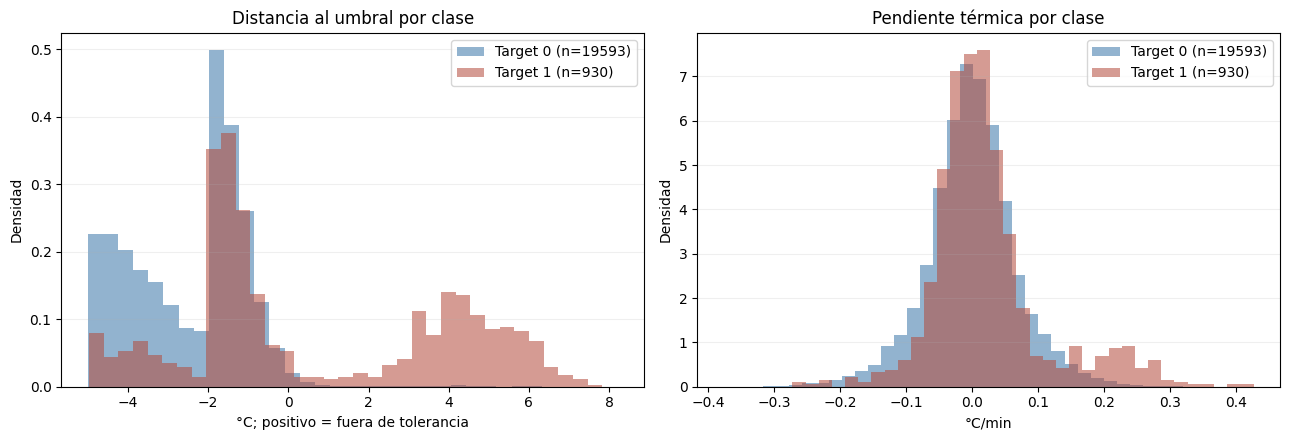

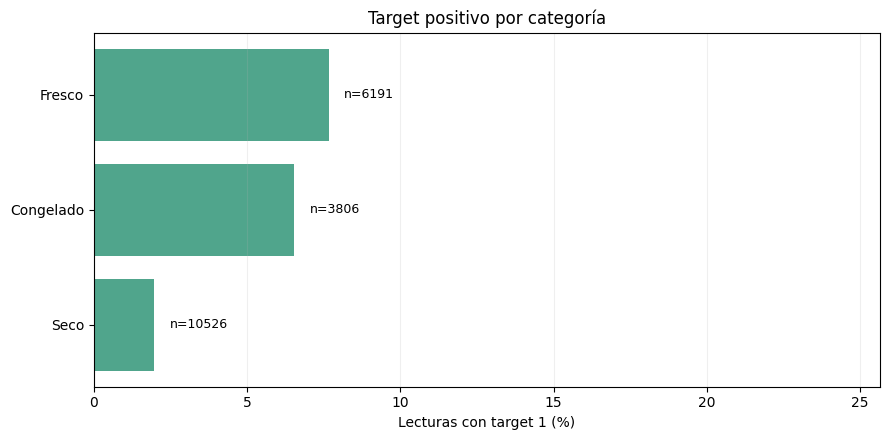

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for clase, color in [(0, "#3976A8"), (1, "#B44A3A")]:
    parte = modelado.loc[modelado[TARGET].eq(clase)]
    axes[0].hist(parte["distancia_umbral_c"], bins=35, alpha=.55, density=True,
                 label=f"Target {clase} (n={len(parte)})", color=color)
    axes[1].hist(parte["temp_pendiente_c_por_min"], bins=35, alpha=.55, density=True,
                 label=f"Target {clase} (n={len(parte)})", color=color)
axes[0].set(title="Distancia al umbral por clase", xlabel="°C; positivo = fuera de tolerancia", ylabel="Densidad")
axes[1].set(title="Pendiente térmica por clase", xlabel="°C/min", ylabel="Densidad")
for ax in axes:
    ax.legend()
    ax.grid(axis="y", alpha=.2)
fig.tight_layout()
plt.show()

grupos = tasa_por_grupo("categoria_logistica").sort_values("tasa_pct")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(grupos["categoria_logistica"].astype(str), grupos["tasa_pct"], color="#50A58C")
for y, (_, fila) in enumerate(grupos.iterrows()):
    ax.text(fila["tasa_pct"] + .5, y, f"n={int(fila['lecturas'])}", va="center", fontsize=9)
ax.set_xlim(0, max(10, min(115, float(grupos["tasa_pct"].max()) + 18)))
ax.set(title="Target positivo por categoría", xlabel="Lecturas con target 1 (%)")
ax.grid(axis="x", alpha=.2)
fig.tight_layout()
plt.show()

## 10 · `X`, `y` y separación temporal candidata

Las features se declaran explícitamente y el target queda separado. La separación candidata ordena **viajes completos** por inicio: train incluye viajes que terminan al menos 60 minutos antes del corte; test, viajes que empiezan desde el corte. Los viajes que cruzan el corte o el margen de 60 minutos quedan fuera de ambos. Así las ventanas de las etiquetas de train no alcanzan el periodo de test. No se ajustan transformaciones, imputadores ni modelos en este notebook.

La selección final del corte debe revisar cobertura temporal, clases en ambos conjuntos y posible cambio de condiciones operativas. Ninguna métrica de clasificación o algoritmo definitivo se fija aquí.

In [9]:
X = modelado[FEATURES].copy()
y = modelado[TARGET].astype(int).copy()
assert TARGET not in X.columns
assert X.index.equals(y.index)

viajes_candidatos = modelado["viaje_id"].unique()
ventanas = (analitico.loc[analitico["viaje_id"].isin(viajes_candidatos)]
            .groupby("viaje_id")["timestamp"].agg(inicio="min", fin="max")
            .sort_values("inicio"))
if len(ventanas) < 3:
    print("Hay menos de tres viajes candidatos: no se propone train/test temporal todavía.")
    X_train = X_test = y_train = y_test = None
else:
    posicion = min(len(ventanas) - 1, max(1, int(np.floor(FRACCION_TRAIN_OBJETIVO * len(ventanas)))))
    corte_temporal = ventanas.iloc[posicion]["inicio"]
    margen_target = pd.Timedelta(minutes=60)
    viajes_train = ventanas.index[ventanas["fin"].add(margen_target).lt(corte_temporal)]
    viajes_test = ventanas.index[ventanas["inicio"].ge(corte_temporal)]
    viajes_cruzan = ventanas.index.difference(viajes_train.union(viajes_test))
    mask_train = modelado["viaje_id"].isin(viajes_train)
    mask_test = modelado["viaje_id"].isin(viajes_test)
    X_train, y_train = X.loc[mask_train], y.loc[mask_train]
    X_test, y_test = X.loc[mask_test], y.loc[mask_test]
    print("Corte temporal candidato:", corte_temporal)
    print("Viajes train/test/cruzan o margen de 60 min:", len(viajes_train), len(viajes_test), len(viajes_cruzan))
    print("Lecturas train/test:", len(X_train), len(X_test))
    if len(X_train) and len(X_test):
        assert set(modelado.loc[mask_train, "viaje_id"]).isdisjoint(set(modelado.loc[mask_test, "viaje_id"]))
        assert modelado.loc[mask_train, "timestamp"].max() < modelado.loc[mask_test, "timestamp"].min()
        assert ventanas.loc[viajes_train, "fin"].max() + margen_target < ventanas.loc[viajes_test, "inicio"].min()
        display(pd.concat([balance(modelado.loc[mask_train], "Train"),
                           balance(modelado.loc[mask_test], "Test")], ignore_index=True).round(2))
        if y_train.nunique() < 2 or y_test.nunique() < 2:
            print("Advertencia: un conjunto contiene una sola clase; revisar el corte antes de modelar.")
    else:
        print("Advertencia: el corte deja train o test vacío; revisar ventanas de viajes.")

Corte temporal candidato: 2026-08-24 18:54:00
Viajes train/test/cruzan o margen de 60 min: 710 181 14
Lecturas train/test: 16099 4107


,conjunto,target,lecturas,porcentaje
0,Train,0,15385,95.56
1,Train,1,714,4.44
2,Test,0,3895,94.84
3,Test,1,212,5.16


## 11 · Interpretación y controles antes del modelado

Redacta al menos tres hallazgos con **observación, cifra, posible acción y límite**. Examina prevalencia del target, diferencia entre clases para las variables numéricas, grupos con tasas elevadas y tamaño suficiente, y pérdida de cobertura desde Silver hasta el conjunto candidato.

Antes de modelar, documenta: **(1)** regla exacta que generó `desviacion_proximos_60min_flag`; **(2)** tratamiento de lecturas cercanas al fin del viaje sin 60 minutos futuros observables; **(3)** momento en que se conocían parámetros del producto y tipo de camión; **(4)** viajes con identidad inestable y posibles huecos temporales; **(5)** corte temporal final, clases por partición y baseline. Si la bandera futura se calculó usando información que no estaría disponible en operación, el resultado puede sobreestimar la utilidad de una alerta real.

In [10]:
print(f"ALCANCE: {len(analitico):,} lecturas de {analitico['viaje_id'].nunique():,} viajes; "
      f"{int(analitico[TARGET].sum()):,} target positivo ({100*analitico[TARGET].mean():.2f} %).")
print(f"CANDIDATO: {len(modelado):,} lecturas ({100*len(modelado)/len(analitico):.2f} % del analítico); "
      f"{modelado['viaje_id'].nunique():,} viajes de identidad estable.")
print(f"COBERTURA: {int(analitico['match_producto'].ne('both').sum()):,} lecturas sin producto; "
      f"{int(analitico['match_flota'].ne('both').sum()):,} sin flota; "
      f"{int((~analitico['viaje_identidad_estable']).sum()):,} en viajes ambiguos.")
print("PENDIENTE: auditar construcción y horizonte del target, revisar el corte y definir baseline antes de entrenar.")
print("Validaciones correctas. Los Silver no se modificaron.")

ALCANCE: 28,425 lecturas de 1,200 viajes; 1,318 target positivo (4.64 %).
CANDIDATO: 20,523 lecturas (72.20 % del analítico); 905 viajes de identidad estable.
COBERTURA: 4,984 lecturas sin producto; 2,389 sin flota; 0 en viajes ambiguos.
PENDIENTE: auditar construcción y horizonte del target, revisar el corte y definir baseline antes de entrenar.
Validaciones correctas. Los Silver no se modificaron.
